In [ ]:
# --- IMPORT LIBRARIES ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----- LOAD DATASETS --------
# LIAR dataset
df_liar_train = pd.read_csv("/kaggle/input/liar-fake-news-dataset/train.tsv", sep="\t", header=None)
df_liar_valid = pd.read_csv("/kaggle/input/liar-fake-news-dataset/valid.tsv", sep="\t", header=None)
df_liar_test = pd.read_csv("/kaggle/input/liar-fake-news-dataset/test.tsv", sep="\t", header=None)
# ISOT dataset
df_isot_fake = pd.read_csv("/kaggle/input/isot-fake-news-dataset/News_Dataset/Fake.csv")
df_isot_true = pd.read_csv("/kaggle/input/isot-fake-news-dataset/News_Dataset/True.csv")
# FakeNewsNet dataset
df_fakenewsnet_buzzfeed_fake = pd.read_csv("/kaggle/input/fakenewsnet/BuzzFeed_fake_news_content.csv")
df_fakenewsnet_buzzfeed_true = pd.read_csv("/kaggle/input/fakenewsnet/BuzzFeed_real_news_content.csv")
df_fakenewsnet_politifact_fake = pd.read_csv("/kaggle/input/fakenewsnet/PolitiFact_fake_news_content.csv")
df_fakenewsnet_politifact_true = pd.read_csv("/kaggle/input/fakenewsnet/PolitiFact_real_news_content.csv")

In [3]:
# Output columns without headings or labels
df_liar_valid.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,12134.json,barely-true,We have less Americans working now than in the...,"economy,jobs",vicky-hartzler,U.S. Representative,Missouri,republican,1,0,1,0,0,an interview with ABC17 News
1,238.json,pants-fire,"When Obama was sworn into office, he DID NOT u...","obama-birth-certificate,religion",chain-email,NaN,NaN,none,11,43,8,5,105,NaN
2,7891.json,false,Says Having organizations parading as being so...,"campaign-finance,congress,taxes",earl-blumenauer,U.S. representative,Oregon,democrat,0,1,1,1,0,a U.S. Ways and Means hearing
3,8169.json,half-true,Says nearly half of Oregons children are poor.,poverty,jim-francesconi,Member of the State Board of Higher Education,Oregon,none,0,1,1,1,0,an opinion article
4,929.json,half-true,On attacks by Republicans that various program...,"economy,stimulus",barack-obama,President,Illinois,democrat,70,71,160,163,9,interview with CBS News


In [4]:
# Add column names to the dataset
df_liar_train.columns = ["ID", "label", "statement", "subjects", "speaker", "speaker_job", "state", "party", 'barely true counts', 'false counts', 'half true counts', 'mostly true counts', 'pants on fire counts', "venue"]
df_liar_valid.columns = ["ID", "label", "statement", "subjects", "speaker", "speaker_job", "state", "party", 'barely true counts', 'false counts', 'half true counts', 'mostly true counts', 'pants on fire counts', "venue"]
df_liar_test.columns = ["ID", "label", "statement", "subjects", "speaker", "speaker_job", "state", "party", 'barely true counts', 'false counts', 'half true counts', 'mostly true counts', 'pants on fire counts', "venue"]

# Dataset with column headings
df_liar_train.head()

,ID,label,statement,subjects,speaker,speaker_job,state,party,barely true counts,false counts,half true counts,mostly true counts,pants on fire counts,venue
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [5]:
# Remove unneeded columns keeping only label, statement columns
df_liar_train.drop(["ID", "subjects", "speaker", "speaker_job", "state", "party", 'barely true counts', 'false counts', 'half true counts', 'mostly true counts', 'pants on fire counts', "venue"], axis=1, inplace=True)
df_liar_valid.drop(["ID", "subjects", "speaker", "speaker_job", "state", "party", 'barely true counts', 'false counts', 'half true counts', 'mostly true counts', 'pants on fire counts', "venue"], axis=1, inplace=True)
df_liar_test.drop(["ID", "subjects", "speaker", "speaker_job", "state", "party", 'barely true counts', 'false counts', 'half true counts', 'mostly true counts', 'pants on fire counts', "venue"], axis=1, inplace=True)

# Combine all 3 sets into one coherent corpus
df_liar_combined = pd.concat([df_liar_train,df_liar_valid, df_liar_test],axis=0).sample(frac = 1, random_state = 42).reset_index(drop = True)

# We'll need our ensemble to produce a real(true) or fake(false) classification.
liar_df_label_mapping = {
    'true': 1,
    'mostly-true': 1,
    'half-true': 0,
    'barely-true': 0,
    'false': 0,
    'pants-fire': 0
}
df_liar_filtered = df_liar_combined[df_liar_combined['label'].isin(liar_df_label_mapping.keys())]

# Replace text labels with numerical ones
df_liar_filtered['label'] = df_liar_filtered['label'].str.lower().map(liar_df_label_mapping)

# Add column for dataset name to know which dataset this came from
df_liar_filtered["source_df"] = "liar"

df_liar_filtered.sample(5)

,label,statement,source_df
8828,0,This is the first time since the Depression th...,liar
5278,0,Sen. George LeMieux voted to let oil companies...,liar
1057,1,Kendrick Meek claims hes the only candidate wh...,liar
12027,0,According to a recent Congressional Budget Off...,liar
662,1,It is legal in Ohio to fire an employee or evi...,liar


In [6]:
# LIAR dataset cleaning
print("LIAR Duplicate records: ", df_liar_filtered.duplicated().sum())
print("LIAR Null Values: \n", df_liar_filtered.isnull().sum())

LIAR Duplicate records:  23
LIAR Null Values: 
 label        0
statement    0
source_df    0
dtype: int64


In [7]:
# Clean null values & duplicate records
df_liar_filtered = df_liar_filtered.drop_duplicates()
df_liar_filtered.reset_index(drop=True, inplace=True)

print("LIAR shape: ", df_liar_filtered.shape)
print("LIAR Duplicates count:", df_liar_filtered.duplicated().sum())
print("LIAR Null Values: \n", df_liar_filtered.isnull().sum())

LIAR shape:  (12768, 3)
LIAR Duplicates count: 0
LIAR Null Values: 
 label        0
statement    0
source_df    0
dtype: int64


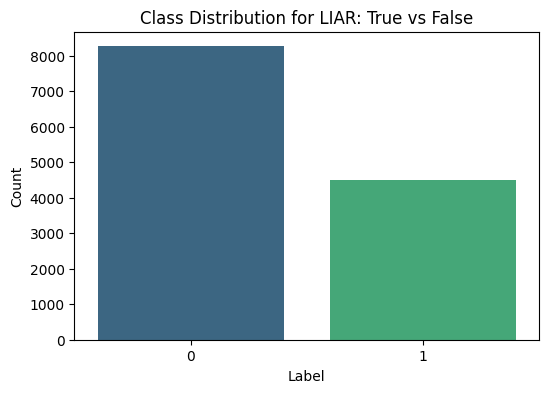

In [8]:
# Bar Chart visualization
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_liar_filtered, palette='viridis')
plt.title('Class Distribution for LIAR: True vs False')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [9]:
# What does the dataset look like?
df_isot_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [10]:
# Create labels for the ISOT datasets
df_isot_fake["label"] = 0
df_isot_true["label"] = 1
df_isot_combined = pd.concat([df_isot_fake,df_isot_true],axis=0).sample(frac = 1, random_state = 42).reset_index(drop = True)

# Remove date and subject columns
df_isot_combined.drop(["date", "subject"], axis=1, inplace=True)

# Check for null values  and duplicates
print("ISOT Duplicates count:", df_isot_combined.duplicated().sum())
print("ISOT Null Values: \n", df_isot_combined.isnull().sum())

ISOT Duplicates count: 5793
ISOT Null Values: 
 title    0
text     0
label    0
dtype: int64


In [11]:
# Clean duplicate records
df_isot_filtered = df_isot_combined.drop_duplicates()
df_isot_filtered.reset_index(drop=True, inplace=True)

# Create new 'statement' column
df_isot_filtered = df_isot_filtered.copy()
df_isot_filtered["statement"] = df_isot_filtered["title"] + " " + df_isot_filtered["text"];

# Remove title and text columns, keep only label and statement columns
df_isot_filtered.drop(["title", "text"], axis=1, inplace=True)

# Add column for dataset name to know which dataset this came from
df_isot_filtered["source_df"] = "isot"

print("ISOT Shape: ", df_isot_filtered.shape)
print("ISOT Duplicates count:", df_isot_filtered.duplicated().sum())
print("ISOT Null Values: \n", df_isot_filtered.isnull().sum())

ISOT Shape:  (39105, 3)
ISOT Duplicates count: 0
ISOT Null Values: 
 label        0
statement    0
source_df    0
dtype: int64


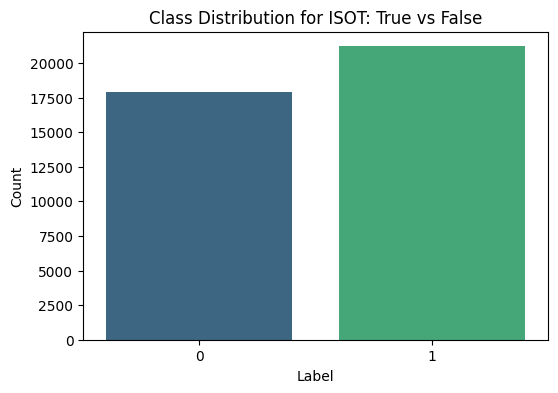

In [12]:
# Bar Chart visualization
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_isot_filtered, palette='viridis')
plt.title('Class Distribution for ISOT: True vs False')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [13]:
# What do the indivivual datasets look like?
df_fakenewsnet_buzzfeed_fake.head()

,id,title,text,url,top_img,authors,source,publish_date,movies,images,canonical_link,meta_data
0,Fake_1-Webpage,Proof The Mainstream Media Is Manipulating The...,I woke up this morning to find a variation of ...,http://www.addictinginfo.org/2016/09/19/proof-...,http://addictinginfo.addictinginfoent.netdna-c...,Wendy Gittleson,http://www.addictinginfo.org,{'$date': 1474243200000},NaN,"http://i.imgur.com/JeqZLhj.png,http://addictin...",http://addictinginfo.com/2016/09/19/proof-the-...,"{""publisher"": ""Addicting Info | The Knowledge ..."
1,Fake_10-Webpage,Charity: Clinton Foundation Distributed “Water...,Former President Bill Clinton and his Clinton ...,http://eaglerising.com/36899/charity-clinton-f...,http://eaglerising.com/wp-content/uploads/2016...,View All Posts,http://eaglerising.com,{'$date': 1474416521000},NaN,http://constitution.com/wp-content/uploads/201...,http://eaglerising.com/36899/charity-clinton-f...,"{""description"": ""The possibility that CHAI dis..."
2,Fake_11-Webpage,A Hillary Clinton Administration May be Entire...,After collapsing just before trying to step in...,http://eaglerising.com/36880/a-hillary-clinton...,http://eaglerising.com/wp-content/uploads/2016...,"View All Posts,Tony Elliott",http://eaglerising.com,{'$date': 1474416638000},NaN,http://constitution.com/wp-content/uploads/201...,http://eaglerising.com/36880/a-hillary-clinton...,"{""description"": ""Hillary Clinton may be the fi..."
3,Fake_12-Webpage,Trump’s Latest Campaign Promise May Be His Mos...,"Donald Trump is, well, deplorable. He’s sugges...",http://www.addictinginfo.org/2016/09/19/trumps...,http://addictinginfo.addictinginfoent.netdna-c...,John Prager,http://www.addictinginfo.org,{'$date': 1474243200000},NaN,"http://i.imgur.com/JeqZLhj.png,http://2.gravat...",http://addictinginfo.com/2016/09/19/trumps-lat...,"{""publisher"": ""Addicting Info | The Knowledge ..."
4,Fake_13-Webpage,Website is Down For Maintenance,Website is Down For Maintenance,http://www.proudcons.com/clinton-foundation-ca...,NaN,NaN,http://www.proudcons.com,NaN,NaN,NaN,NaN,"{""og"": {""url"": ""http://www.proudcons.com"", ""ty..."


In [14]:
# remove unneeded columns
df_fakenewsnet_buzzfeed_fake.drop(["id", "url", "top_img", "authors", "source", "publish_date", "movies", "images", "canonical_link", "meta_data"], axis=1, inplace=True)
df_fakenewsnet_buzzfeed_true.drop(["id", "url", "top_img", "authors", "source", "publish_date", "movies", "images", "canonical_link", "meta_data"], axis=1, inplace=True)
df_fakenewsnet_politifact_fake.drop(["id", "url", "top_img", "authors", "source", "publish_date", "movies", "images", "canonical_link", "meta_data"], axis=1, inplace=True)
df_fakenewsnet_politifact_true.drop(["id", "url", "top_img", "authors", "source", "publish_date", "movies", "images", "canonical_link", "meta_data"], axis=1, inplace=True)

# Create new 'label' column
df_fakenewsnet_buzzfeed_fake["label"] = 0
df_fakenewsnet_buzzfeed_true["label"] = 1
df_fakenewsnet_politifact_fake["label"] = 0
df_fakenewsnet_politifact_true["label"] = 1

# Create new 'statement' column
df_fakenewsnet_buzzfeed_fake["statement"] = df_fakenewsnet_buzzfeed_fake["title"] + " " + df_fakenewsnet_buzzfeed_fake["text"]
df_fakenewsnet_buzzfeed_true["statement"] = df_fakenewsnet_buzzfeed_true["title"] + " " + df_fakenewsnet_buzzfeed_true["text"]
df_fakenewsnet_politifact_fake["statement"] = df_fakenewsnet_politifact_fake["title"] + " " + df_fakenewsnet_politifact_fake["text"]
df_fakenewsnet_politifact_true["statement"] = df_fakenewsnet_politifact_true["title"] + " " + df_fakenewsnet_politifact_true["text"]

# Combine the modified datasets
df_fakenewsnet_combined = pd.concat([df_fakenewsnet_buzzfeed_fake,df_fakenewsnet_buzzfeed_true, df_fakenewsnet_politifact_fake, df_fakenewsnet_politifact_true],axis=0).sample(frac = 1, random_state = 42).reset_index(drop = True)

# remove title and text column from combined dataset
df_fakenewsnet_combined.drop(["title", "text"], axis=1, inplace=True)

df_fakenewsnet_combined.sample(5)

,label,statement
380,0,Former Miss Universe sizes up Melania Trump: '...
357,0,Charity: Clinton Foundation Distributed “Water...
111,0,Secret Video Records MASSIVE Hillary Event Flo...
133,1,Trump camp: ‘Donald Trump is guilty of answeri...
272,0,New York bomb Suspect SUED Police! New York bo...


In [15]:
# Check for null values  and duplicates
print("FakeNewsNet Duplicates count:", df_fakenewsnet_combined.duplicated().sum())
print("FakeNewsNet Null Values: \n", df_fakenewsnet_combined.isnull().sum())

FakeNewsNet Duplicates count: 19
FakeNewsNet Null Values: 
 label        0
statement    0
dtype: int64


In [16]:
# Clean duplicate records
df_fakenewsnet_filtered = df_fakenewsnet_combined.drop_duplicates()
df_fakenewsnet_filtered.reset_index(drop=True, inplace=True)

# Add column for dataset name to know which dataset this came from
df_fakenewsnet_filtered["source_df"] = "fakenewsnet"

print("FakeNewsNet Shape: ", df_fakenewsnet_filtered.shape)
print("FakeNewsNet Duplicates count:", df_fakenewsnet_filtered.duplicated().sum())
print("FakeNewsNet Null Values: \n", df_fakenewsnet_filtered.isnull().sum())

FakeNewsNet Shape:  (403, 3)
FakeNewsNet Duplicates count: 0
FakeNewsNet Null Values: 
 label        0
statement    0
source_df    0
dtype: int64


/tmp/ipykernel_40/3233772363.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fakenewsnet_filtered["source_df"] = "fakenewsnet"


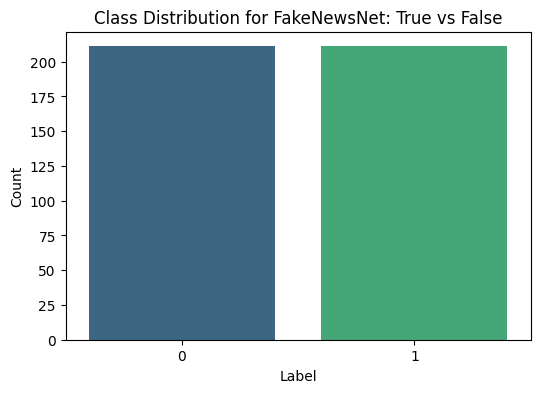

In [17]:
# Bar Chart visualization
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_fakenewsnet_combined, palette='viridis')
plt.title('Class Distribution for FakeNewsNet: True vs False')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [18]:
# Combine all 3 datasets into one
df_total_combined = pd.concat([df_liar_filtered,df_isot_filtered, df_fakenewsnet_filtered],axis=0).sample(frac = 1, random_state = 42).reset_index(drop = True)

df_total_combined.shape

(52276, 3)

In [ ]:
"""
===========================================================
B.U.S.T. (Bogus Text Uncovering System)
Comprehensive Fake News Detection Pipeline
===========================================================

Features:
---------
✔ Uses pre-merged dataframe: df_total_combined
✔ NLP preprocessing with NLTK + spaCy
✔ TF-IDF feature engineering
✔ Multiple ML models
✔ Hyperparameter tuning
✔ Model evaluation
✔ Automatic best model selection
✔ Model export/import
✔ Reusable inference pipeline
✔ Production-ready architecture

Execution inside notebook: train_pipeline(df_total_combined)

===========================================================
"""

# =========================================================
# IMPORTS
# =========================================================

from __future__ import annotations

import logging
import random
import re
import warnings
from pathlib import Path
from typing import Dict

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import spacy

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV

from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    train_test_split,
)

from sklearn.naive_bayes import MultinomialNB

from sklearn.preprocessing import LabelEncoder

from sklearn.svm import LinearSVC

from xgboost import XGBClassifier

# =========================================================
# WARNINGS
# =========================================================

warnings.filterwarnings("ignore")

# =========================================================
# CONFIGURATION
# =========================================================

RANDOM_STATE = 42

TEST_SIZE = 0.2

MAX_FEATURES = 50000

MODEL_PATH = "fake_news_model.pkl"

VECTORIZER_PATH = "tfidf_vectorizer.pkl"

LABEL_ENCODER_PATH = "label_encoder.pkl"

PLOTS_DIR = Path("plots")

PLOTS_DIR.mkdir(exist_ok=True)

random.seed(RANDOM_STATE)

np.random.seed(RANDOM_STATE)

# =========================================================
# LOGGING
# =========================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logger = logging.getLogger(__name__)

# =========================================================
# DOWNLOAD NLP RESOURCES
# =========================================================

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# =========================================================
# SPACY MODEL
# =========================================================

try:
    NLP = spacy.load("en_core_web_sm")

except Exception:

    logger.warning(
        "spaCy model missing. "
        "Run: python -m spacy download en_core_web_sm"
    )

    NLP = spacy.blank("en")

# =========================================================
# NLP GLOBALS
# =========================================================

STOPWORDS = set(stopwords.words("english"))

LEMMATIZER = WordNetLemmatizer()

# =========================================================
# LABEL NORMALIZATION
# =========================================================

def normalize_labels(label):

    """
    Convert labels into:
        FAKE -> 0
        REAL -> 1
    """

    if isinstance(label, str):

        label = label.strip().lower()

        fake_values = [
            "fake",
            "false",
            "pants-fire",
            "pants on fire",
            "barely-true",
            "barely true",
        ]

        real_values = [
            "real",
            "true",
            "mostly-true",
            "mostly true",
            "half-true",
            "half true",
        ]

        if label in fake_values:
            return 0

        if label in real_values:
            return 1

    return int(label)

# =========================================================
# TEXT CLEANING
# =========================================================

def clean_text(text: str) -> str:

    """
    Basic text cleaning.
    """

    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = re.sub(r"http\S+", " ", text)

    text = re.sub(r"www\S+", " ", text)

    text = re.sub(r"<.*?>", " ", text)

    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\d+", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

# =========================================================
# NLP PREPROCESSING
# =========================================================

def preprocess_text(text: str) -> str:

    """
    Full NLP preprocessing pipeline.
    """

    try:

        text = clean_text(text)

        if not text:
            return ""

        doc = NLP(text)

        tokens = []

        for token in doc:

            word = token.text.strip()

            if (
                word
                and word not in STOPWORDS
                and len(word) > 2
            ):

                lemma = (
                    token.lemma_
                    if token.lemma_ != "-PRON-"
                    else word
                )

                lemma = LEMMATIZER.lemmatize(lemma)

                tokens.append(lemma)

        return " ".join(tokens)

    except Exception as error:

        logger.error(
            f"Preprocessing failed: {error}"
        )

        return ""

# =========================================================
# FEATURE ENGINEERING
# =========================================================

def build_vectorizer(vectorizer_type="tfidf"):

    """
    Create text vectorizer.
    """

    if vectorizer_type == "count":

        return CountVectorizer(
            max_features=MAX_FEATURES,
            ngram_range=(1, 2),
            stop_words="english"
        )

    return TfidfVectorizer(
        max_features=MAX_FEATURES,
        ngram_range=(1, 2),
        stop_words="english",
        sublinear_tf=True,
        min_df=2,
        max_df=0.95
    )

# =========================================================
# MODELS
# =========================================================

def get_models() -> Dict:

    """
    Initialize ML models.
    """
    return {

        "LogisticRegression": LogisticRegression(
            max_iter=500,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

        "LinearSVM": CalibratedClassifierCV(
            LinearSVC(random_state=RANDOM_STATE)
        ),

        "NaiveBayes": MultinomialNB(),
    }

# =========================================================
# HYPERPARAMETER TUNING
# =========================================================

def tune_model(model_name, model, X_train, y_train):

    """
    Hyperparameter tuning.
    """

    logger.info(f"Tuning {model_name}")

    try:

        if model_name == "LogisticRegression":

            params = {
                "C": [0.1, 1, 5],
                "solver": ["liblinear"]
            }

            search = GridSearchCV(
                model,
                params,
                scoring="f1",
                cv=3,
                n_jobs=-1
            )

        elif model_name == "RandomForest":

            params = {
                "n_estimators": [100, 200],
                "max_depth": [10, 20, None]
            }

            search = RandomizedSearchCV(
                model,
                params,
                n_iter=3,
                scoring="f1",
                cv=3,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

        else:
            return model

        search.fit(X_train, y_train)

        logger.info(
            f"Best params: {search.best_params_}"
        )

        return search.best_estimator_

    except Exception as error:

        logger.error(
            f"Tuning failed: {error}"
        )

        return model

# =========================================================
# MODEL EVALUATION
# =========================================================

def evaluate_model(
    model_name,
    model,
    X_test,
    y_test
):

    """
    Evaluate trained model.
    """

    predictions = model.predict(X_test)

    if hasattr(model, "predict_proba"):

        probabilities = model.predict_proba(X_test)[:, 1]

    else:

        probabilities = predictions

    metrics = {

        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions
        ),

        "Recall": recall_score(
            y_test,
            predictions
        ),

        "F1": f1_score(
            y_test,
            predictions
        ),

        "ROC_AUC": roc_auc_score(
            y_test,
            probabilities
        ),
    }

    logger.info(
        f"{model_name} F1: {metrics['F1']:.4f}"
    )

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.tight_layout()

    plt.savefig(
        PLOTS_DIR /
        f"{model_name}_confusion_matrix.png"
    )

    plt.close()

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    report = classification_report(
        y_test,
        predictions
    )

    logger.info(f"\n{report}")

    return metrics

# =========================================================
# MODEL EXPORT
# =========================================================

def export_model(
    model,
    vectorizer,
    label_encoder
):

    """
    Save model artifacts.
    """

    joblib.dump(model, MODEL_PATH)

    joblib.dump(
        vectorizer,
        VECTORIZER_PATH
    )

    joblib.dump(
        label_encoder,
        LABEL_ENCODER_PATH
    )

    logger.info(
        "Model artifacts saved."
    )

# =========================================================
# MODEL LOADING
# =========================================================

def load_saved_artifacts():

    """
    Load saved artifacts.
    """

    model = joblib.load(MODEL_PATH)

    vectorizer = joblib.load(
        VECTORIZER_PATH
    )

    label_encoder = joblib.load(
        LABEL_ENCODER_PATH
    )

    return model, vectorizer, label_encoder

# =========================================================
# INFERENCE
# =========================================================

def predict_news(text: str):

    """
    Predict fake/real news.
    """

    if not text or len(text.strip()) < 15:

        raise ValueError(
            "Input text too short."
        )

    model, vectorizer, _ = (
        load_saved_artifacts()
    )

    processed = preprocess_text(text)

    vectorized = vectorizer.transform(
        [processed]
    )

    prediction = model.predict(
        vectorized
    )[0]

    if hasattr(model, "predict_proba"):

        probabilities = model.predict_proba(
            vectorized
        )[0]

        fake_prob = float(probabilities[0])

        real_prob = float(probabilities[1])

    else:

        fake_prob = float(1 - prediction)

        real_prob = float(prediction)

    label = (
        "REAL"
        if prediction == 1
        else "FAKE"
    )

    confidence = (
        real_prob
        if label == "REAL"
        else fake_prob
    )

    return {

        "prediction": label,

        "confidence": round(
            confidence,
            4
        ),

        "probabilities": {

            "FAKE": round(
                fake_prob,
                4
            ),

            "REAL": round(
                real_prob,
                4
            ),
        },
    }

# =========================================================
# TRAINING PIPELINE
# =========================================================

def train_pipeline(
    df_total_combined: pd.DataFrame
):

    """
    Complete ML pipeline.
    """

    logger.info(
        "Starting training pipeline..."
    )

    # =====================================================
    # VALIDATE DATAFRAME
    # =====================================================

    if df_total_combined.empty:

        raise ValueError(
            "Input dataframe is empty."
        )

    df = df_total_combined.copy()

    # =====================================================
    # FIND TEXT COLUMN
    # =====================================================

    possible_text_columns = [
        "statement",
        "text",
        "title",
        "content"
    ]

    text_column = None

    for col in possible_text_columns:

        if col in df.columns:

            text_column = col

            break

    if text_column is None:

        raise ValueError(
            "No text column found."
        )

    # =====================================================
    # FIND LABEL COLUMN
    # =====================================================

    possible_label_columns = [
        "label",
        "labels",
        "target"
    ]

    label_column = None

    for col in possible_label_columns:

        if col in df.columns:

            label_column = col

            break

    if label_column is None:

        raise ValueError(
            "No label column found."
        )

    # =====================================================
    # CLEAN DATAFRAME
    # =====================================================

    df = df[[text_column, label_column]]

    df.columns = [
        "statement",
        "label"
    ]

    df.dropna(inplace=True)

    df.drop_duplicates(inplace=True)

    df["statement"] = (
        df["statement"]
        .astype(str)
        .str.strip()
    )

    df = df[
        df["statement"].str.len() > 10
    ]

    # =====================================================
    # NORMALIZE LABELS
    # =====================================================

    df["label"] = df["label"].apply(
        normalize_labels
    )

    logger.info(
        f"Dataset shape: {df.shape}"
    )

    # =====================================================
    # NLP PREPROCESSING
    # =====================================================

    logger.info(
        "Preprocessing text..."
    )

    df["processed"] = (
        df["statement"]
        .apply(preprocess_text)
    )

    # =====================================================
    # FEATURES + TARGET
    # =====================================================

    X = df["processed"]

    y = df["label"]

    # =====================================================
    # LABEL ENCODER
    # =====================================================

    label_encoder = LabelEncoder()

    y_encoded = label_encoder.fit_transform(y)

    # =====================================================
    # TRAIN TEST SPLIT
    # =====================================================

    X_train, X_test, y_train, y_test = (
        train_test_split(
            X,
            y_encoded,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            stratify=y_encoded
        )
    )

    # =====================================================
    # TF-IDF
    # =====================================================

    logger.info(
        "Vectorizing text..."
    )

    vectorizer = build_vectorizer(
        "tfidf"
    )

    X_train_vec = vectorizer.fit_transform(
        X_train
    )

    X_test_vec = vectorizer.transform(
        X_test
    )

    # =====================================================
    # TRAIN MODELS
    # =====================================================

    models = get_models()

    results = []

    best_model = None

    best_score = 0

    best_name = None

    for model_name, model in models.items():

        try:

            logger.info(
                f"Training {model_name}..."
            )

            tuned_model = clone(model)

            tuned_model.fit(
                X_train_vec,
                y_train
            )

            metrics = evaluate_model(
                model_name,
                tuned_model,
                X_test_vec,
                y_test
            )

            results.append(metrics)

            if metrics["F1"] > best_score:

                best_score = metrics["F1"]

                best_model = tuned_model

                best_name = model_name

        except Exception as error:

            logger.error(
                f"{model_name} failed: {error}"
            )

    # =====================================================
    # RESULTS
    # =====================================================

    results_df = pd.DataFrame(results)

    results_df.sort_values(
        by="F1",
        ascending=False,
        inplace=True
    )

    print("\n===== MODEL COMPARISON =====")

    print(results_df)

    # =====================================================
    # PERFORMANCE PLOT
    # =====================================================

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=results_df,
        x="Model",
        y="F1"
    )

    plt.xticks(rotation=25)

    plt.title(
        "Model Performance Comparison"
    )

    plt.tight_layout()

    plt.savefig(
        PLOTS_DIR / "model_comparison.png"
    )

    plt.close()

    # =====================================================
    # SAVE BEST MODEL
    # =====================================================

    logger.info(
        f"Best model: {best_name}"
    )

    export_model(
        best_model,
        vectorizer,
        label_encoder
    )

    logger.info(
        "Training completed."
    )

    return (
        best_model,
        vectorizer,
        label_encoder,
        results_df
    )

# =========================================================
# MAIN EXECUTION
# =========================================================

if __name__ == "__main__":

    print(
        "\nFake News Detection System Ready.\n"
    )

    print(
        "Use:\n"
        "train_pipeline(df_total_combined)"
    )


Fake News Detection System Ready.

Use:
train_pipeline(df_total_combined)


In [ ]:
best_model, vectorizer, label_encoder, results = train_pipeline(
    df_total_combined
)

In [23]:
from pathlib import Path

print(Path("fake_news_model.pkl").exists())
print(Path("tfidf_vectorizer.pkl").exists())
print(Path("label_encoder.pkl").exists())

True
True
True
